In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA


In [53]:
day_raw = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/day.csv")
hour_raw = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/hour.csv")



In [54]:
TARGET = "cnt"
LEAK_COLS = ["cnt", "casual", "registered"]


In [55]:
y_hour = hour_raw[TARGET]
y_day  = day_raw[TARGET]


In [56]:
def basic_clean(df):
    df = df.copy()

    # Convert date
    df["dteday"] = pd.to_datetime(df["dteday"])

    # Drop leakage columns
    df.drop(columns=LEAK_COLS, errors="ignore", inplace=True)

    # Fill missing numeric values safely
    df.fillna(df.median(numeric_only=True), inplace=True)

    return df


In [57]:
hour = basic_clean(hour_raw)
day  = basic_clean(day_raw)


HOUR Dataset

In [58]:
def feature_engineer_hour(df):
    df = df.copy()

    # Cyclical hour encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

    # Calendar features
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)
    df["is_rush_hour"] = df["hr"].isin([7,8,9,17,18,19]).astype(int)

    # Weather interactions
    df["temp_hum"] = df["temp"] * df["hum"]
    df["temp_wind"] = df["temp"] * df["windspeed"]
    df["bad_weather"] = df["weathersit"].isin([3,4]).astype(int)

    # Seasonal flags
    df["summer"] = (df["season"] == 2).astype(int)
    df["winter"] = (df["season"] == 4).astype(int)

    # Time trend (SAFE – no target)
    df["trend"] = np.arange(len(df))

    # Convert date to ordinal
    df["dteday"] = df["dteday"].map(pd.Timestamp.toordinal)

    # Drop raw cyclical column
    df.drop(columns=["hr"], inplace=True)

    return df


DAY DATASET

In [59]:
def feature_engineer_day(df):
    df = df.copy()

    # Cyclical month encoding
    df["month_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)

    # Calendar features
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

    # Weather interactions
    df["temp_hum"] = df["temp"] * df["hum"]
    df["temp_wind"] = df["temp"] * df["windspeed"]
    df["bad_weather"] = df["weathersit"].isin([3,4]).astype(int)

    # Seasonal flags
    df["summer"] = (df["season"] == 2).astype(int)
    df["winter"] = (df["season"] == 4).astype(int)

    # Trend
    df["trend"] = np.arange(len(df))

    # Date ordinal
    df["dteday"] = df["dteday"].map(pd.Timestamp.toordinal)

    df.drop(columns=["mnth"], inplace=True)

    return df


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [61]:
X_hour = feature_engineer_hour(hour)
X_day  = feature_engineer_day(day)


In [62]:
def time_split(X, y, ratio=0.8):
    split = int(len(X) * ratio)
    return (
        X.iloc[:split],
        X.iloc[split:],
        y.iloc[:split],
        y.iloc[split:]
    )


In [63]:
X_train_hour, X_test_hour, y_train_hour, y_test_hour = time_split(X_hour, y_hour)
X_train_day,  X_test_day,  y_train_day,  y_test_day  = time_split(X_day, y_day)


In [64]:
num_cols_hour = X_train_hour.select_dtypes(include=np.number).columns
num_cols_day  = X_train_day.select_dtypes(include=np.number).columns

scaler_hour = StandardScaler()
X_train_hour_scaled = scaler_hour.fit_transform(X_train_hour[num_cols_hour])
X_test_hour_scaled  = scaler_hour.transform(X_test_hour[num_cols_hour])

scaler_day = StandardScaler()
X_train_day_scaled = scaler_day.fit_transform(X_train_day[num_cols_day])
X_test_day_scaled  = scaler_day.transform(X_test_day[num_cols_day])


In [65]:
pca_hour = PCA(n_components=0.95, random_state=42)
X_train_hour_pca = pca_hour.fit_transform(X_train_hour_scaled)
X_test_hour_pca  = pca_hour.transform(X_test_hour_scaled)

pca_day = PCA(n_components=0.95, random_state=42)
X_train_day_pca = pca_day.fit_transform(X_train_day_scaled)
X_test_day_pca  = pca_day.transform(X_test_day_scaled)


In [66]:
models_hour = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}


In [67]:
models_day = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

In [68]:
def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


In [69]:
trained_hour_models = {}
results_hour = []

for name, model in models_hour.items():
    if name == "Linear Regression":
        model.fit(X_train_hour_pca, y_train_hour)
        preds = model.predict(X_test_hour_pca)
    else:
        model.fit(X_train_hour, y_train_hour)
        preds = model.predict(X_test_hour)

    trained_hour_models[name] = model

    res = evaluate(y_test_hour, preds)
    res["Model"] = name
    results_hour.append(res)

hour_results_df = pd.DataFrame(results_hour).sort_values("R2", ascending=False)
hour_results_df


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1578
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 23
[LightGBM] [Info] Start training from score 174.639143


,R2,RMSE,MAE,Model
5,0.902004,69.021133,43.587357,LightGBM
4,0.894790,71.516661,44.219246,XGBoost
2,0.868749,79.878558,48.538131,Random Forest
3,0.830349,90.814863,62.284942,Gradient Boosting
1,0.799617,98.698189,60.978136,Decision Tree
0,0.557958,146.592029,108.533087,Linear Regression


In [70]:
trained_day_models = {}
results_day = []

for name, model in models_day.items():
    if name == "Linear Regression":
        model.fit(X_train_day_pca, y_train_day)
        preds = model.predict(X_test_day_pca)
    else:
        model.fit(X_train_day, y_train_day)
        preds = model.predict(X_test_day)

    trained_day_models[name] = model

    res = evaluate(y_test_day, preds)
    res["Model"] = name
    results_day.append(res)

day_results_df = pd.DataFrame(results_day).sort_values("R2", ascending=False)
day_results_df


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1802
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 19
[LightGBM] [Info] Start training from score 4153.599315
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,R2,RMSE,MAE,Model
5,0.666292,1082.920542,727.993309,LightGBM
3,0.661619,1090.476613,725.540102,Gradient Boosting
4,0.644479,1117.752544,739.914307,XGBoost
2,0.596195,1191.239628,837.143707,Random Forest
0,0.510693,1311.305406,985.653876,Linear Regression
1,0.378480,1477.886253,1114.238095,Decision Tree


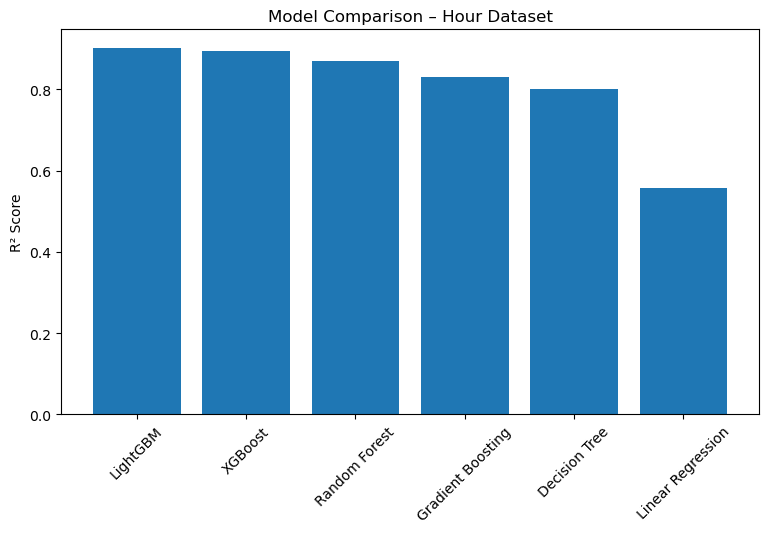

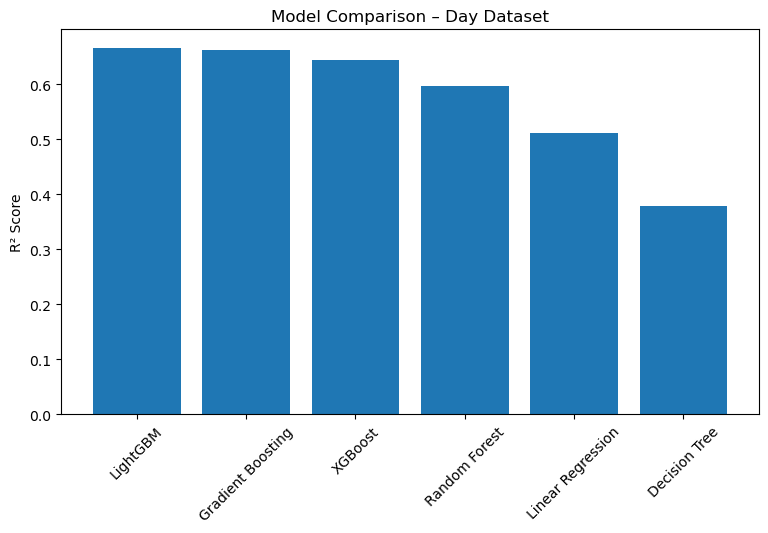

In [71]:
import matplotlib.pyplot as plt

# Hour
plt.figure(figsize=(9,5))
plt.bar(hour_results_df["Model"], hour_results_df["R2"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Comparison – Hour Dataset")
plt.show()

# Day
plt.figure(figsize=(9,5))
plt.bar(day_results_df["Model"], day_results_df["R2"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Comparison – Day Dataset")
plt.show()


<Figure size 800x600 with 0 Axes>

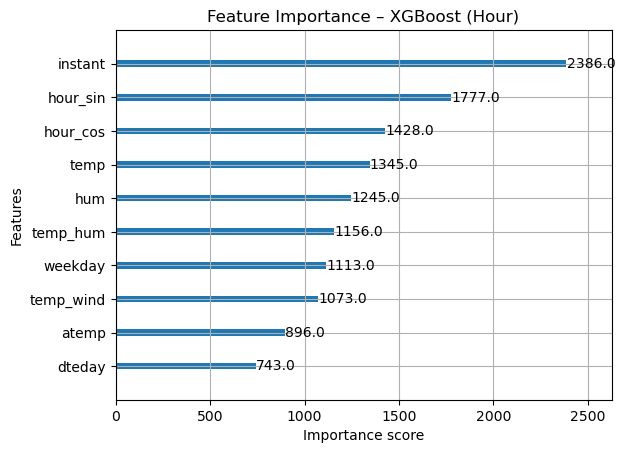

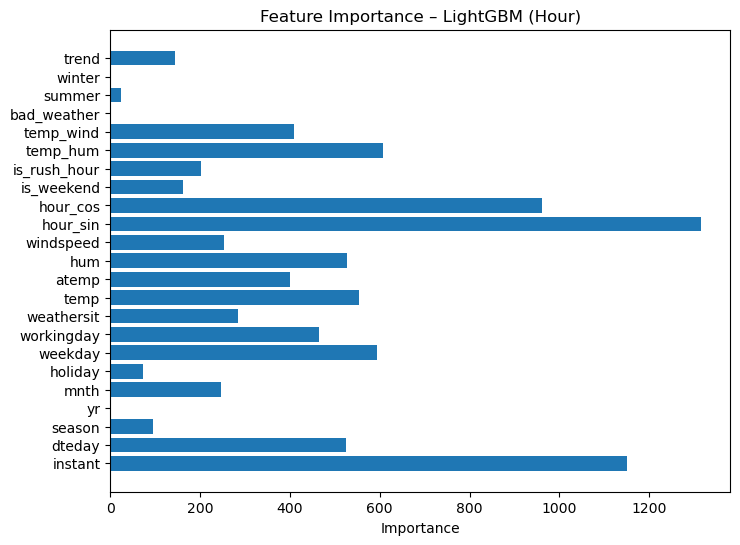

In [46]:
# Hour dataset
xgb_hour = trained_hour_models["XGBoost"]
lgbm_hour = trained_hour_models["LightGBM"]

y_pred_xgb = xgb_hour.predict(X_test_hour)
y_pred_lgbm = lgbm_hour.predict(X_test_hour)
from xgboost import plot_importance

# XGBoost importance
plt.figure(figsize=(8,6))
plot_importance(xgb_hour, max_num_features=10)
plt.title("Feature Importance – XGBoost (Hour)")
plt.show()

# LightGBM importance
plt.figure(figsize=(8,6))
plt.barh(X_train_hour.columns, lgbm_hour.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance – LightGBM (Hour)")
plt.show()


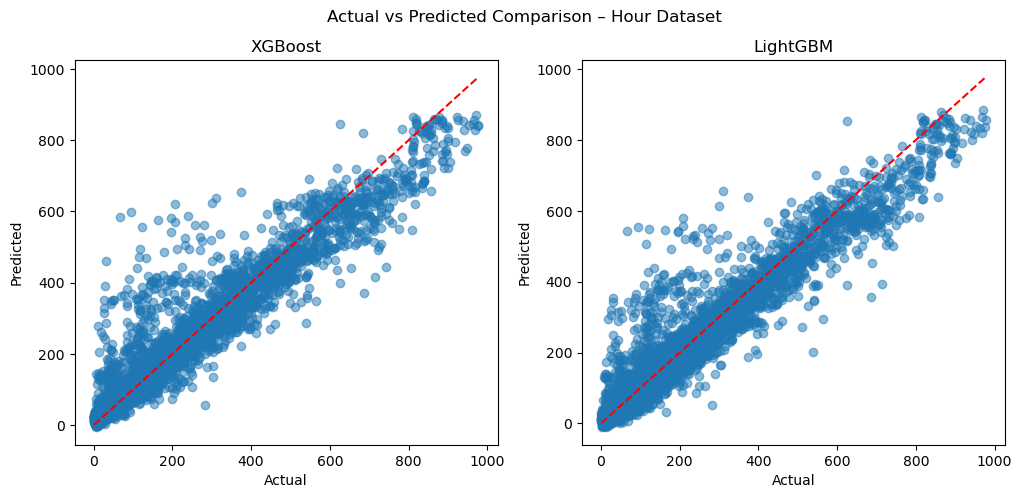

In [72]:


# Actual vs Predicted Comparison
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# XGBoost
axes[0].scatter(y_test_hour, y_pred_xgb, alpha=0.5)
axes[0].plot([y_test_hour.min(), y_test_hour.max()],
             [y_test_hour.min(), y_test_hour.max()], 'r--')
axes[0].set_title("XGBoost")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# LightGBM
axes[1].scatter(y_test_hour, y_pred_lgbm, alpha=0.5)
axes[1].plot([y_test_hour.min(), y_test_hour.max()],
             [y_test_hour.min(), y_test_hour.max()], 'r--')
axes[1].set_title("LightGBM")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.suptitle("Actual vs Predicted Comparison – Hour Dataset")
plt.show()


In [48]:
# Best models based on R²
best_hour_model_name = hour_results_df.iloc[0]["Model"]
best_day_model_name  = day_results_df.iloc[0]["Model"]

print("Best Hour Model:", best_hour_model_name)
print("Best Day Model :", best_day_model_name)

best_hour_model = trained_hour_models[best_hour_model_name]
best_day_model  = trained_day_models[best_day_model_name]


Best Hour Model: LightGBM
Best Day Model : LightGBM


In [49]:
import joblib

joblib.dump(best_hour_model, "best_hour_model.pkl")
joblib.dump(best_day_model, "best_day_model.pkl")


['best_day_model.pkl']

In [50]:
joblib.dump(scaler_hour, "hour_scaler.pkl")
joblib.dump(pca_hour, "hour_pca.pkl")


['hour_pca.pkl']

In [51]:
joblib.dump(scaler_day, "day_scaler.pkl")
joblib.dump(pca_day, "day_pca.pkl")


['day_pca.pkl']